# Features, and the classics reproduced

This notebook builds the Tuckman-Chang measures on Canadian data, implements
their 0-4 scoring rule, and re-estimates the Greenlee-Trussel (2000) and Trussel
(2002) logits. The point is to establish that the benchmarks are faithfully
implemented **before** `03-model-results` compares anything against them — a
benchmark that loses because it was built carelessly proves nothing.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from charity_risk import config, plots
from charity_risk.benchmarks import (
    GREENLEE_TRUSSEL_2000, TC_RISK_DIRECTION, TRUSSEL_2002,
    TuckmanChangScore, fit_statsmodels_logit,
)
from charity_risk.dataset import load_dataset, exit_split, vulnerability_split
from charity_risk.features import FEATURE_GROUPS, TUCKMAN_CHANG, TRUSSEL_RATIOS

plots.use_project_style()
pd.set_option("display.width", 200)

columns = sorted({c for group in FEATURE_GROUPS.values() for c in group}) + [
    "exit_next_year", "vulnerable", "total_revenue", "net_assets"]
frame = load_dataset(years=[2019, 2020, 2021], columns=columns)
train, test = exit_split(frame)
print(f"train {config.TRAIN_YEAR}: {len(train):,} rows, exit rate {train['exit_next_year'].mean():.2%}")
print(f"test  {config.TEST_YEAR}: {len(test):,} rows, exit rate {test['exit_next_year'].mean():.2%}")

train 2020: 84,344 rows, exit rate 1.82%
test  2021: 84,339 rows, exit rate 2.04%


## 1. The four Tuckman-Chang measures on Canadian data

| Measure | T3010 construction | Risky tail |
|---|---|---|
| Equity balance | (4200 − 4350) / 4700 | low |
| Revenue concentration | Herfindahl over the eight harmonised buckets | high |
| Administrative cost ratio | 5010 / 4950 | **low** |
| Operating margin | (4700 − 5100) / 4700 | low |

Two construction choices are worth flagging.

*Denominators.* About 6% of charity-years report zero revenue. A ratio with a
vanishing denominator is coded missing, not as a large finite number — otherwise
a structurally distinct group would be scattered through the tail of a continuous
feature, and the winsorising step would then read them as outliers to be clipped.

*Concentration.* The index runs over the harmonised buckets from
`01-data-and-outcomes`, not over the raw lines, so a Section D filer is not
mechanically assigned a higher concentration for reporting fewer lines.

In [2]:
described = train[list(TUCKMAN_CHANG)].describe(percentiles=[.05, .25, .5, .75, .95]).T
described["missing"] = train[list(TUCKMAN_CHANG)].isna().mean()
described["risky_tail"] = [("low" if TC_RISK_DIRECTION[r] < 0 else "high") for r in described.index]
described[["count", "missing", "5%", "25%", "50%", "75%", "95%", "risky_tail"]].round(3)

,count,missing,5%,25%,50%,75%,95%,risky_tail
equity_balance,79803.0,0.054,0.000,0.267,1.066,4.695,28.097,low
revenue_concentration,80238.0,0.049,0.315,0.480,0.656,0.909,1.000,high
admin_cost_ratio,79371.0,0.059,0.000,0.000,0.062,0.202,1.000,low
operating_margin,79803.0,0.054,-1.169,-0.047,0.062,0.243,0.857,low


The tails are extreme and genuine. An operating margin of −38,000 belongs to a
charity that reported one dollar of revenue against forty thousand of spending.
Those rows are real and are not dropped; the model pipelines winsorise at the
training-sample 1st and 99th percentiles instead, with the cut-points learned
inside the pipeline so the test year never informs them.

## 2. The scoring rule

Tuckman and Chang flag a charity on each measure when it falls in the risky
quintile, and count the flags. `TuckmanChangScore` implements exactly that, with
one discipline the original did not need: the quintile cut-points are **fitted on
the training year and applied unchanged to the test year**, so the rule faces the
same information constraint as every fitted model it is compared against.

Missing ratios do not count as flags. A Section D filer with no administrative
cost line is scored on the three measures it does have — counting missingness as
a flag would turn the score into a proxy for filing tier.

In [3]:
scorer = TuckmanChangScore().fit(train[list(TUCKMAN_CHANG)], train["exit_next_year"])
pd.DataFrame({
    "cutpoint_2020": pd.Series(scorer.cutpoints_),
    "risky_tail": pd.Series({r: ("bottom quintile" if d < 0 else "top quintile")
                             for r, d in TC_RISK_DIRECTION.items()}),
}).round(4)

,cutpoint_2020,risky_tail
equity_balance,0.1683,bottom quintile
revenue_concentration,0.9525,top quintile
admin_cost_ratio,0.0000,bottom quintile
operating_margin,-0.1014,bottom quintile


In [4]:
test_scored = test.assign(
    tc_score=scorer.score(test[list(TUCKMAN_CHANG)]),
    n_ratios_scored=scorer.n_ratios_scored(test[list(TUCKMAN_CHANG)]),
)
distribution = pd.DataFrame({
    "n_charities": test_scored.groupby("tc_score").size(),
    "exit_rate": test_scored.groupby("tc_score")["exit_next_year"].mean(),
    "mean_ratios_available": test_scored.groupby("tc_score")["n_ratios_scored"].mean(),
})
distribution["lift"] = distribution["exit_rate"] / test_scored["exit_next_year"].mean()
distribution.round(3)

,n_charities,exit_rate,mean_ratios_available,lift
tc_score,,,,
0.0,36262,0.017,3.624,0.841
1.0,30443,0.016,3.827,0.781
2.0,13434,0.027,3.929,1.307
3.0,3770,0.054,3.982,2.640
4.0,430,0.121,4.000,5.930


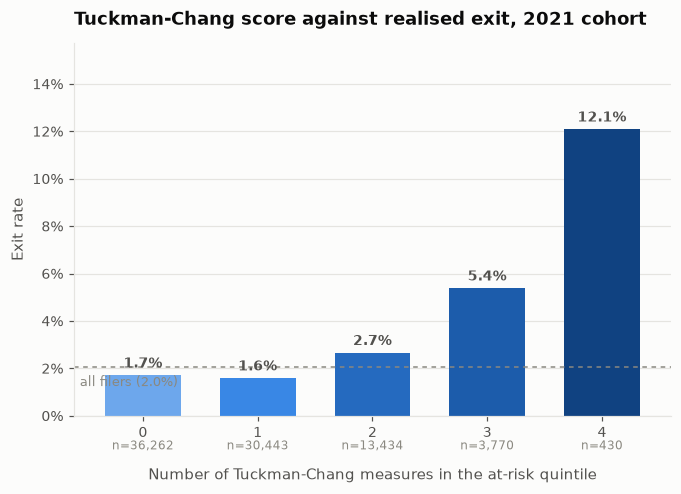

In [5]:
fig, ax = plots.plt.subplots(figsize=(7.0, 4.4))
plots.plot_score_response(test_scored, "tc_score", "exit_next_year", ax=ax,
                          title="Tuckman-Chang score against realised exit, 2021 cohort");

**The rule works, in the direction its authors claimed, and it is nearly
useless as a screen.** Both halves of that sentence matter.

It works: charities flagged on all four measures exit at 12.1%, seven times the
1.7% rate of those flagged on none. Thirty years on, in a different country and a
different regulatory system, the four measures still sort risk.

It is nearly useless as a screen: only 430 of 84,000 charities score 4. The
score-0 and score-1 groups — 79% of the register between them — have
indistinguishable exit rates (1.7% and 1.6%), so for four charities in five the
rule returns no information at all. `03-model-results` puts a number on the cost:
the 0-4 count achieves an AUC of 0.587 against 0.842 for a model with access to
the same underlying ratios plus size, age and dynamics. The problem is not the
measures. It is the discretisation.

One cut-point deserves a note. The administrative cost ratio's bottom-quintile
threshold comes out at exactly **0.0000**, because more than a fifth of Canadian
charities report no management-and-administration expense at all. So in practice
that flag does not mean "unusually lean"; it means "reported nothing on line
5010", which is as much a statement about filing as about cost structure.

## 3. Greenlee and Trussel (2000), re-estimated

The four ratios in a logistic regression, on the outcome they defined: net assets
falling 20% or more over three years. We fit on the 2019 cohort, resolved against
2022.

In [6]:
vuln_frame = load_dataset(years=[2019, 2020], columns=columns)
vuln_train, vuln_test = vulnerability_split(vuln_frame)
print(f"2019 cohort: {len(vuln_train):,} labelled, {vuln_train['vulnerable'].mean():.1%} vulnerable")

gt = fit_statsmodels_logit(vuln_train, "vulnerable", GREENLEE_TRUSSEL_2000["numeric"])
gt.summary2().tables[1].round(4)

2019 cohort: 68,630 labelled, 17.9% vulnerable


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
const,-1.8632,0.0321,-58.0155,0.0000,-1.9262,-1.8003
equity_balance,-0.0131,0.0011,-11.5689,0.0000,-0.0154,-0.0109
revenue_concentration,0.5285,0.0457,11.5563,0.0000,0.4389,0.6182
admin_cost_ratio,0.0311,0.0408,0.7608,0.4468,-0.0489,0.1111
operating_margin,-0.3043,0.0140,-21.7900,0.0000,-0.3316,-0.2769


Every sign matches the published model. Higher revenue concentration raises the
probability of a net-asset decline; a stronger equity balance and a healthier
operating margin lower it. The administrative cost ratio is insignificant — which
is also what Trussel found two years later, and part of why he re-specified.

## 4. Trussel (2002), re-estimated

Revenue concentration, surplus margin, debt ratio and administrative cost ratio,
plus a size control and sector fixed effects.

In [7]:
tr_fit = fit_statsmodels_logit(vuln_train, "vulnerable", TRUSSEL_2002["numeric"],
                               TRUSSEL_2002["categorical"])
tr_fit.summary2().tables[1].round(4)

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
const,0.7894,0.0716,11.0182,0.0000,0.6490,0.9299
revenue_concentration,0.3106,0.0462,6.7200,0.0000,0.2200,0.4011
surplus_margin,-0.1763,0.0120,-14.6275,0.0000,-0.1999,-0.1526
debt_ratio,-0.1115,0.0457,-2.4398,0.0147,-0.2011,-0.0219
admin_cost_ratio,0.0621,0.0411,1.5094,0.1312,-0.0185,0.1427
log_total_assets,-0.2022,0.0049,-41.0201,0.0000,-0.2119,-0.1926
charity_type_Advancement of Religion,-0.1372,0.0339,-4.0427,0.0001,-0.2038,-0.0707
charity_type_Other Purposes Beneficial to the Community,-0.0407,0.0337,-1.2081,0.2270,-0.1067,0.0253
charity_type_Relief of Poverty,-0.1805,0.0414,-4.3546,0.0000,-0.2617,-0.0992


In [8]:
print(f"pseudo R-squared : {tr_fit.prsquared:.4f}")
print(f"log-likelihood   : {tr_fit.llf:,.0f}  (null {tr_fit.llnull:,.0f})")
print(f"n                : {int(tr_fit.nobs):,}")

pseudo R-squared : 0.0395
log-likelihood   : -29,089  (null -30,287)
n                : 65,560


The size coefficient dominates the table: |z| ≈ 41 against 15 for the next
strongest. This is the result that motivates the size-only baseline in the next
notebook. If one variable carries that much of the fit, the honest question is
not "do the ratios add to size" but "does size add to the ratios", and the answer
turns out to be uncomfortable for the classics.

## 5. The same specifications on the exit outcome

Refitting both on permanent deregistration shows how much the outcome definition
matters. The ratios that predict a shrinking balance sheet are not the same ones
that predict deregistration.

In [9]:
gt_exit = fit_statsmodels_logit(train, "exit_next_year", GREENLEE_TRUSSEL_2000["numeric"])
tr_exit = fit_statsmodels_logit(train, "exit_next_year", TRUSSEL_2002["numeric"],
                                TRUSSEL_2002["categorical"])

comparison = pd.DataFrame({
    "vulnerability": tr_fit.params,
    "vulnerability_z": tr_fit.tvalues,
    "exit": tr_exit.params,
    "exit_z": tr_exit.tvalues,
})
comparison.loc[[i for i in comparison.index if not i.startswith("charity_type")]].round(3)

,vulnerability,vulnerability_z,exit,exit_z
const,0.789,11.018,-1.423,-5.359
revenue_concentration,0.311,6.720,1.163,6.543
surplus_margin,-0.176,-14.627,-0.158,-12.969
debt_ratio,-0.112,-2.440,0.107,1.619
admin_cost_ratio,0.062,1.509,0.263,2.218
log_total_assets,-0.202,-41.020,-0.347,-20.248


Three things change when the outcome changes, and one does not.

**Revenue concentration survives.** Positive and strongly significant on both
outcomes, and roughly four times larger on exit (1.16 against 0.31). Of the four
original Tuckman-Chang measures, this is the one that travels furthest.

**Size matters more, not less.** The log-assets coefficient nearly doubles when
the outcome becomes deregistration (−0.35 against −0.20).

**Debt ratio flips, but weakly.** Significantly negative for vulnerability,
positive but insignificant for exit (z = 1.6). Leverage is partly a marker of
scale and operating history, and the two effects appear to offset once size is
already controlled for.

**The administrative cost ratio runs the wrong way.** It is insignificant for
vulnerability — as Trussel found — but positive and significant for exit
(coefficient 0.26, z = 2.2). *Higher* administrative spending as a share of
expenditure predicts deregistration. That is the opposite of Tuckman and Chang's
slack argument, which treats administrative cost as discretionary padding that a
charity in trouble can cut.

This is a real finding, and it has a consequence for the scoring rule: the
Tuckman-Chang flag on this measure fires on the *bottom* quintile, so on the exit
outcome it is firing on the wrong tail. The 0-4 score is being asked to combine
three measures pointing one way with a fourth pointing the other. Some of its
poor discrimination in `03-model-results` is that mis-signed component rather
than the discretisation alone.

## 6. What we add

The extended feature set keeps everything above and adds five groups. The
motivation in each case is something the 1991-2002 literature could not observe
in cross-sectional Form 990 data, or chose not to use.

| Group | Examples | Why |
|---|---|---|
| `structure` | log revenue, log assets, log age, insolvency and zero-revenue flags | Size and age are the strongest raw correlates of exit; the flags separate structurally distinct states from continuous tails |
| `dynamics` | revenue / asset / expenditure / net-asset growth, consecutive deficit years, tier downgrade | Direction of travel, not just level. A charity dropping from Schedule 6 to the short Section D form has fallen below the small-charity thresholds — a contraction signal invisible in any single ratio |
| `composition` | revenue share by source, donation dependence, earned-income share, program expense ratio | The concentration index throws away *which* source dominates; government dependence and donor dependence carry different risks |
| `liquidity` | months of cash, quick ratio, payables to expenditure, compensation ratio | Balance-sheet detail, available for Schedule 6 filers only |
| `filing` | filer tier, accrual basis, share of asked lines reported nil, returns filed in year | How the return was filed, and how much of it is nil |

In [10]:
for name, group in FEATURE_GROUPS.items():
    print(f"{name:14s} ({len(group):2d})  {', '.join(group)}\n")

tuckman_chang  ( 4)  equity_balance, revenue_concentration, admin_cost_ratio, operating_margin

trussel        ( 5)  revenue_concentration, surplus_margin, debt_ratio, admin_cost_ratio, log_total_assets

structure      (11)  log_total_revenue, log_total_assets, log_age, is_new_entrant, net_assets_to_assets, liabilities_to_revenue, expense_coverage, negative_net_assets, zero_revenue, insolvent, micro_charity

dynamics       ( 8)  revenue_growth, asset_growth, expenditure_growth, net_asset_growth, revenue_growth_volatility, consecutive_deficit_years, revenue_decline_over_30pct, tier_downgrade

composition    (12)  share_receipted_gifts, share_gifts_from_other_charities, share_other_gifts, share_government, share_foreign_non_receipted, share_fundraising, share_sales_of_goods_and_services, share_other, donation_dependence, earned_income_share, program_expense_ratio, donee_gift_share

liquidity      ( 7)  months_of_cash, quick_ratio, payables_to_expenditure, deferred_revenue_share, compensa

Two of these earn their place empirically rather than theoretically, and both
show up in the importance ranking in the next notebook:

* **`share_nil_lines`** — of the lines a filer's tier was asked, the fraction
  reported as nil. It is important to be clear about what this is *not*. A blank
  cell on a line the filer was asked is a **reported zero**, not missing data: a
  Schedule 6 filer that leaves line 4540 empty received no federal government
  revenue. So this is not a measure of filing quality or diligence. It counts
  how many distinct kinds of revenue and expenditure the organisation has at
  all, and a charity reporting nil on nearly every line is a simple or dormant
  one — which is why it predicts deregistration.
* **`n_returns_in_year`** — two returns with periods ending in the same year.
  Almost always a fiscal year-end change, and a stub period is exactly what a
  charity files on the way to winding up or amalgamating.